In [28]:
#Raw Data

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("spotify-tracks-dataset.csv")


df.columns
df


,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [29]:
#---------
#Data Cleaning
#---------
df = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"])
df.duplicated().sum()
df = df.drop_duplicates("track_id")
df.shape

df

df.isnull().sum()
df.isnull().sum().sort_values(ascending=False)
df.dropna()
#df.shape
#(89741, 20)
#df.reset_index()
df["track_id"].nunique()

df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [30]:
df["popularity"].describe()
(df["popularity"] == 0).sum()

model_df = df[df["popularity"] > 0]
model_df["popularity"].describe()
#df = df.drop(columns=["popularity"] == 0 )
model_df.shape


model_df[["popularity", "danceability", "energy", "acousticness", "speechiness"]].corr()["popularity"]

popularity      1.000000
danceability    0.074163
energy         -0.034196
acousticness   -0.006825
speechiness    -0.085061
Name: popularity, dtype: float64

In [31]:
#-------------
#Matplotlib theme
#-------------
plt.style.use("dark_background")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.family"] = "DejaVu Sans"

In [32]:
#print(df.to_string())
print(df.head(30))

                  track_id                               artists  \
0   5SuOikwiRyPMVoIQDJUgSV                           Gen Hoshino   
1   4qPNDBW1i3p13qLCt0Ki3A                          Ben Woodward   
2   1iJBSr7s7jYXzM8EGcbK5b                Ingrid Michaelson;ZAYN   
3   6lfxq3CG4xtTiEg7opyCyx                          Kina Grannis   
4   5vjLSffimiIP26QG5WcN2K                      Chord Overstreet   
5   01MVOl9KtVTNfFiBU9I7dc                          Tyrone Wells   
6   6Vc5wAMmXdKIAM7WUoEb7N  A Great Big World;Christina Aguilera   
7   1EzrEOXmMH3G43AXT1y7pA                            Jason Mraz   
8   0IktbUcnAGrvD03AWnz3Q8             Jason Mraz;Colbie Caillat   
9   7k9GuJYLp2AzqokyEdwEw2                        Ross Copperman   
10  4mzP5mHkRvGxdhdGdAH7EJ                          Zack Tabudlo   
11  5ivF4eQBqJiVL5IAE9jRyl                            Jason Mraz   
12  4ptDJbJl35d7gQfeNteBwp                              Dan Berk   
13  0X9MxHR1rTkEHDjp95F2OO                      

C:\Users\DELL\AppData\Local\Temp\ipykernel_30348\856812514.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


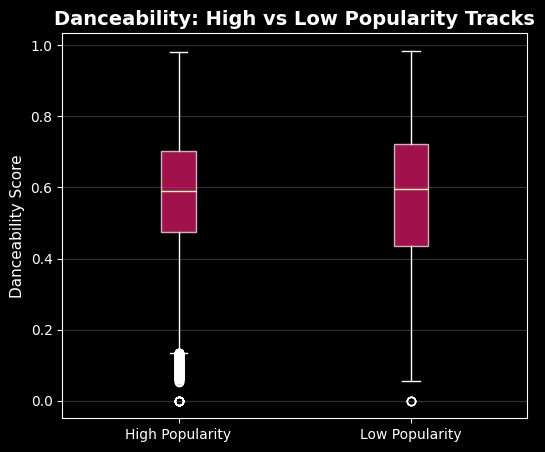

C:\Users\DELL\AppData\Local\Temp\ipykernel_30348\856812514.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


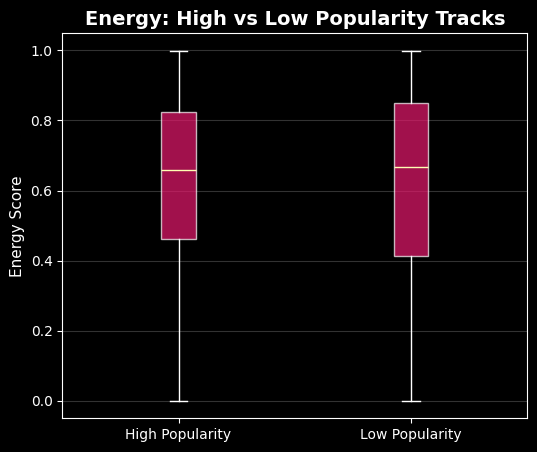

C:\Users\DELL\AppData\Local\Temp\ipykernel_30348\856812514.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


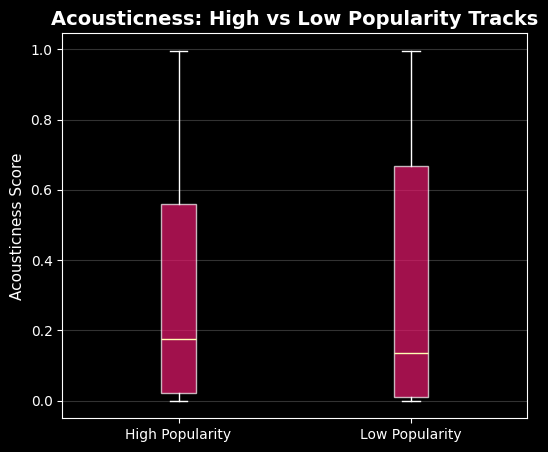

C:\Users\DELL\AppData\Local\Temp\ipykernel_30348\856812514.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


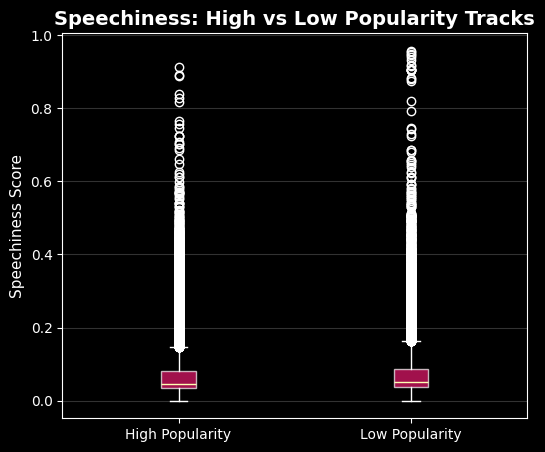

In [33]:
#---------------
#Box Plots -  Audio Features VS Popularity
#---------------

low_pop = df[df["popularity"] <= 17]
high_pop = df[df["popularity"] >= 50]

features = ["danceability", "energy", "acousticness", "speechiness"]

low_pop[features].mean(), high_pop[features].mean()
#Danceability
plt.figure(figsize=(6,5))

box = plt.boxplot(
    [high_pop["danceability"], low_pop["danceability"]],
    labels=["High Popularity", "Low Popularity"],
    patch_artist=True
)

# Set box colors
colors = ["#E6196D", "#E6196D"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title("Danceability: High vs Low Popularity Tracks")
plt.ylabel("Danceability Score")

plt.grid(axis="y", alpha=0.2)

plt.show()


#Energy


plt.figure(figsize=(6,5))

box = plt.boxplot(
    [high_pop["energy"], low_pop["energy"]],
    labels=["High Popularity", "Low Popularity"],
    patch_artist=True
)

# Set box colors
colors = ["#E6196D", "#E6196D"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title("Energy: High vs Low Popularity Tracks")
plt.ylabel("Energy Score")

plt.grid(axis="y", alpha=0.2)

plt.show()


#Acousticness


plt.figure(figsize=(6,5))

box = plt.boxplot(
    [high_pop["acousticness"], low_pop["acousticness"]],
    labels=["High Popularity", "Low Popularity"],
    patch_artist=True
)

# Set box colors
colors = ["#E6196D", "#E6196D"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title("Acousticness: High vs Low Popularity Tracks")
plt.ylabel("Acousticness Score")

plt.grid(axis="y", alpha=0.2)

plt.show()


#Speechiness

plt.figure(figsize=(6,5))

box = plt.boxplot(
    [high_pop["speechiness"], low_pop["speechiness"]],
    labels=["High Popularity", "Low Popularity"],
    patch_artist=True
)

# Set box colors
colors = ["#E6196D", "#E6196D"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title("Speechiness: High vs Low Popularity Tracks")
plt.ylabel("Speechiness Score")

plt.grid(axis="y", alpha=0.2)

plt.show()



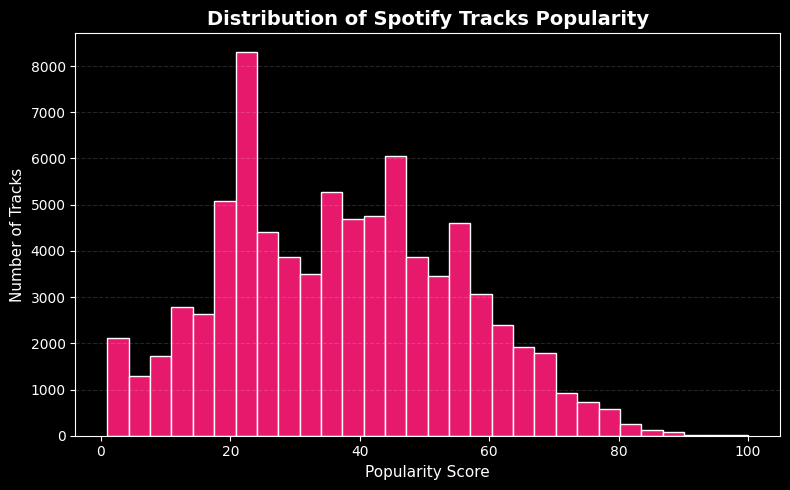

In [34]:
#----------------
#Random Distribution Of Spotify Tracks Popularity (No Specific Order for Tracks)
#----------------
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.hist(model_df["popularity"], bins=30, color="#E6196D", edgecolor="white")

plt.title("Distribution of Spotify Tracks Popularity", fontsize=14, weight="bold")
plt.xlabel("Popularity Score", fontsize=11)
plt.ylabel("Number of Tracks", fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.15)

plt.tight_layout()
plt.show()

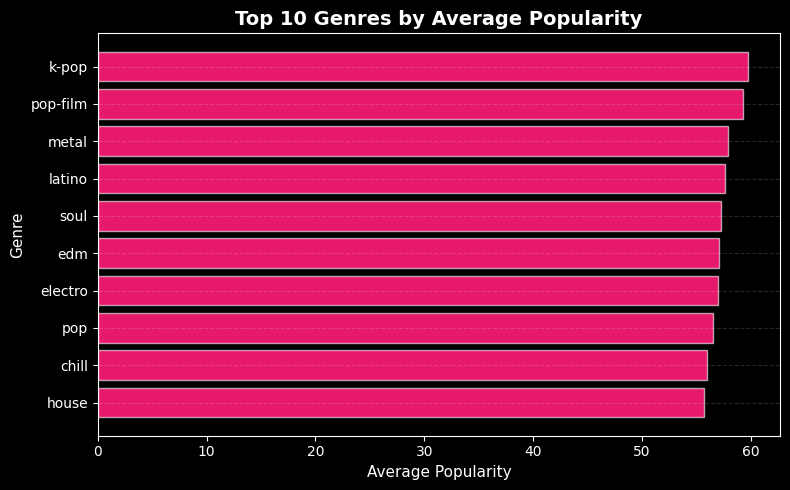

In [ ]:

#----------------
#Top 10 Genres by Average Popularity
#----------------


genre_pop = model_df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False)

genre_pop.head(10)
genre_pop.tail(10)

top10 = genre_pop.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10.index[::-1], top10.values[::-1], color="#E6196D",edgecolor=(1, 1, 1, 0.6))

plt.title("Top 10 Genres by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")

plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.15)
plt.show()

In [36]:
model_df["track_genre"].nunique()
model_df["popularity"].quantile(0.75)


model_df["high_popularity"] = (model_df["popularity"] >= 50).astype(int)

model_df["high_popularity"].value_counts()

high_popularity
0    59084
1    21209
Name: count, dtype: int64

In [ ]:
#----------------
#Features for correlation matrix
#----------------


import matplotlib.pyplot as plt
import numpy as np

plt.style.use("dark_background")

# Select relevant numeric columns
features = [
    'danceability',
    'energy',
    'valence',
    'acousticness',
    'loudness',
    'speechiness',
    'instrumentalness',
    'tempo',
    'popularity'
]

corr_matrix = df[features].corr()

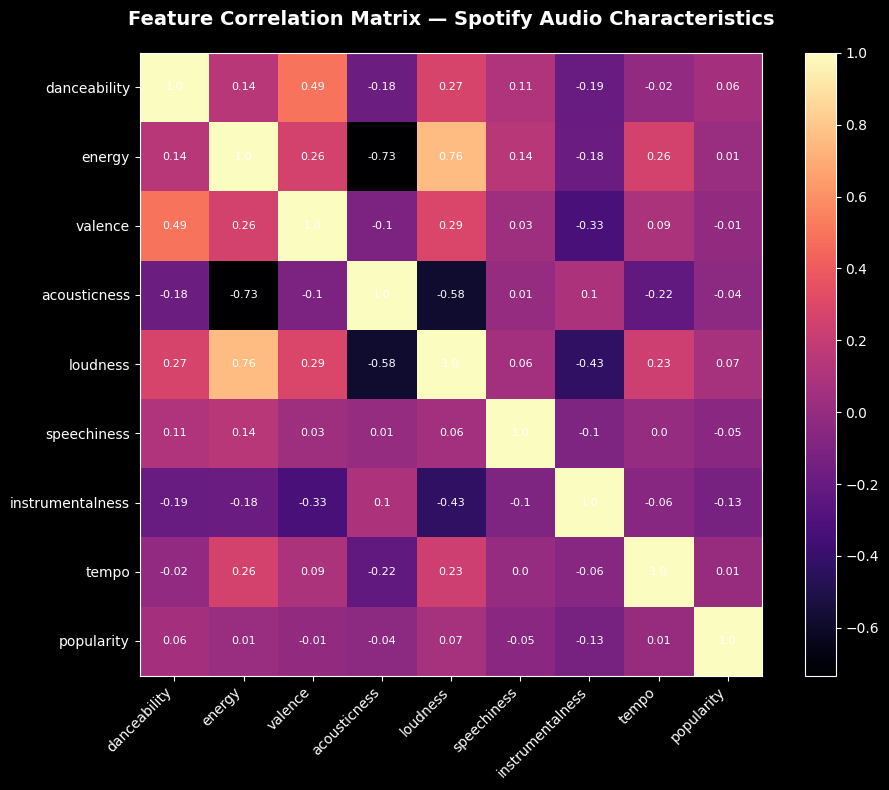

In [ ]:

#----------------
#Correlation Matrix Heatmap
#----------------


fig, ax = plt.subplots(figsize=(10, 8))


cax = ax.imshow(corr_matrix, cmap='magma')

# Add colorbar
cbar = fig.colorbar(cax)

# Add labels
ax.set_xticks(np.arange(len(features)))
ax.set_yticks(np.arange(len(features)))

ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_yticklabels(features)

plt.title("Feature Correlation Matrix — Spotify Audio Characteristics", pad=20)

plt.tight_layout()

for i in range(len(features)):
    for j in range(len(features)):
        text = ax.text(j, i, 
                       round(corr_matrix.iloc[i, j], 2),
                       ha="center", va="center", color="white", fontsize=8)
        
plt.show()

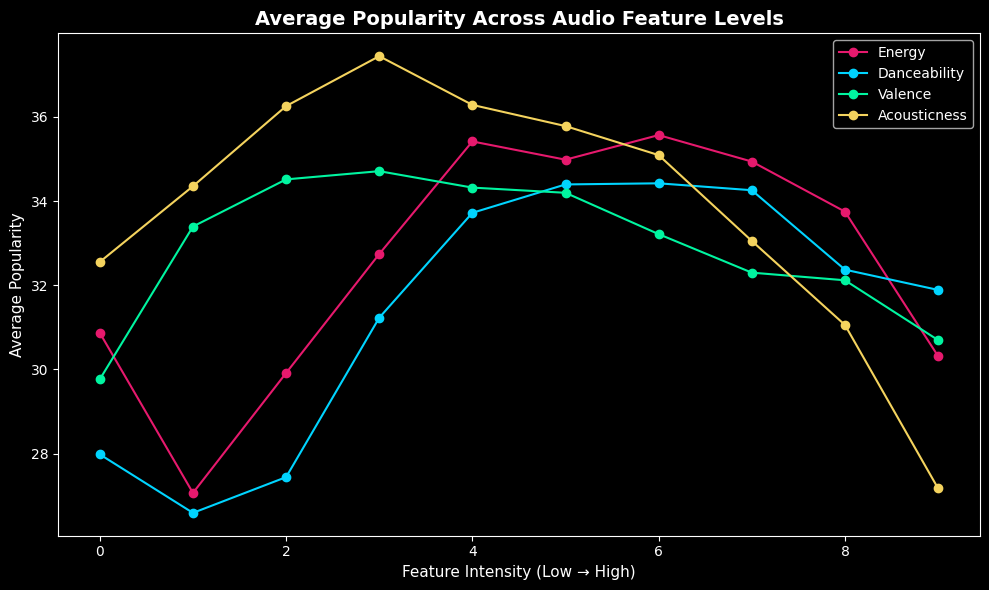

In [39]:

#----------------
#Average Popularity Across Audio Feature Levels
#----------------


plt.style.use("dark_background")

def plot_binned_trend(feature, bins=10):
    df[f'{feature}_bin'] = pd.cut(df[feature], bins=bins)
    grouped = df.groupby(f'{feature}_bin')['popularity'].mean()
    return grouped.values

energy_trend = plot_binned_trend('energy')
dance_trend = plot_binned_trend('danceability')
valence_trend = plot_binned_trend('valence')
acoustic_trend = plot_binned_trend('acousticness')

plt.figure(figsize=(10,6))

x = range(len(energy_trend))

plt.plot(x, energy_trend, marker='o', label='Energy',color ='#E6196D')
plt.plot(x, dance_trend, marker='o', label='Danceability',color= '#00D4FF')
plt.plot(x, valence_trend, marker='o', label='Valence',color='#00F5A0')
plt.plot(x, acoustic_trend, marker='o', label='Acousticness',color='#F4D35E')

plt.xlabel("Feature Intensity (Low → High)")
plt.ylabel("Average Popularity")
plt.title("Average Popularity Across Audio Feature Levels")

plt.legend()
plt.tight_layout()
plt.show()

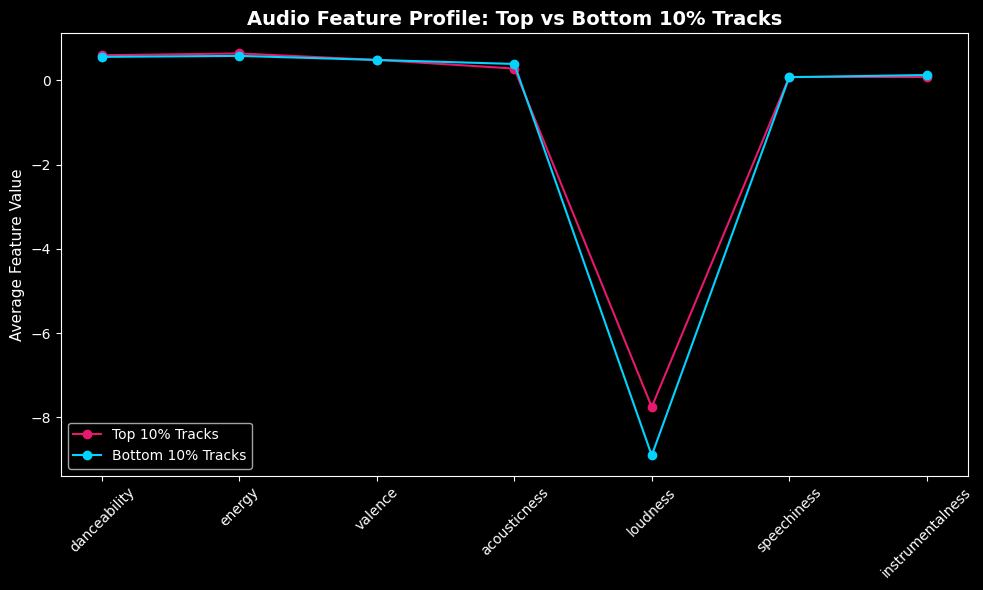

In [ ]:
#----------------
#Audio Feature Profile: Top vs Bottom 10% Tracks
#----------------

top_10 = df[df['popularity'] >= df['popularity'].quantile(0.9)]
bottom_10 = df[df['popularity'] <= df['popularity'].quantile(0.1)]

features = [
    'danceability',
    'energy',
    'valence',
    'acousticness',
    'loudness',
    'speechiness',
    'instrumentalness',
]

top_means = top_10[features].mean()
bottom_means = bottom_10[features].mean()

import matplotlib.pyplot as plt

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

plt.plot(features, top_means, marker='o', label='Top 10% Tracks', color='#E6196D')
plt.plot(features, bottom_means, marker='o', label='Bottom 10% Tracks', color='#00D4FF')

plt.title("Audio Feature Profile: Top vs Bottom 10% Tracks")
plt.ylabel("Average Feature Value")
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

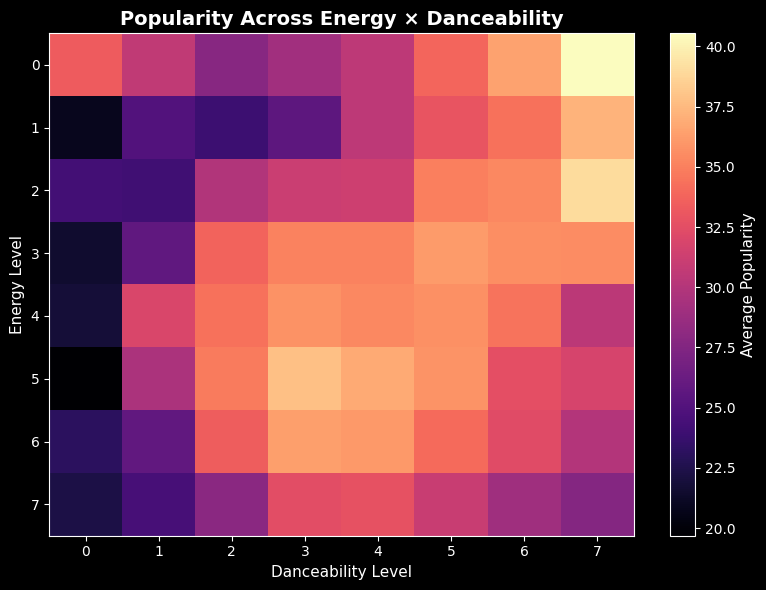

In [ ]:

#-----------
#opularity Across Energy × Danceability
#----------

df['energy_bin'] = pd.cut(df['energy'], bins=8)
df['dance_bin'] = pd.cut(df['danceability'], bins=8)

interaction = df.groupby(['energy_bin','dance_bin'])['popularity'].mean().unstack()

plt.figure(figsize=(8,6))
plt.imshow(interaction, aspect='auto', cmap='magma')

plt.colorbar(label="Average Popularity")

plt.xlabel("Danceability Level")
plt.ylabel("Energy Level")
plt.title("Popularity Across Energy × Danceability")

plt.tight_layout()
plt.show()

Accuracy: 0.9576020948242242

Confusion Matrix:
[[17173   151]
 [  610    15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17324
           1       0.09      0.02      0.04       625

    accuracy                           0.96     17949
   macro avg       0.53      0.51      0.51     17949
weighted avg       0.94      0.96      0.95     17949


ROC AUC Score: 0.6936669591318402


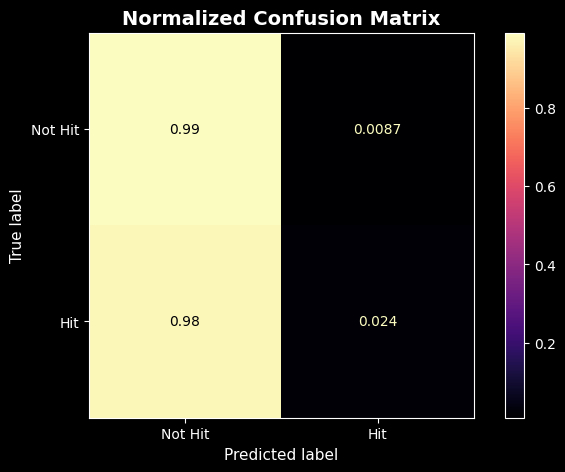


Feature Importance:
instrumentalness    0.114224
acousticness        0.112278
energy              0.106008
loudness            0.104092
duration_ms         0.102176
danceability        0.096383
liveness            0.095791
valence             0.094943
speechiness         0.087302
tempo               0.086803
dtype: float64


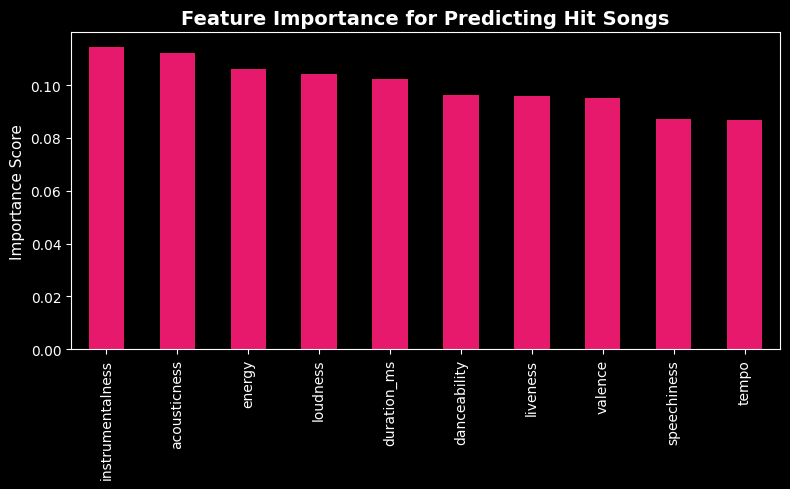

In [ ]:

#ML MODEL

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# -------------------------------
# 1. Create HIT label
# -------------------------------

df['hit'] = (df['popularity'] >= 70).astype(int)

# -------------------------------
# 2. Define features
# -------------------------------

features = [
'danceability',
'energy',
'loudness',
'tempo',
'acousticness',
'instrumentalness',
'speechiness',
'liveness',
'valence',
'duration_ms'
]

X = df[features]
y = df['hit']

# -------------------------------
# 3. Train/Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------------
# 4. Train Random Forest Model
# -------------------------------

model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

# -------------------------------
# 5. Predictions
# -------------------------------

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:,1]

# -------------------------------
# 6. Evaluation
# -------------------------------

print("Accuracy:", accuracy_score(y_test, predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

print("\nROC AUC Score:", roc_auc_score(y_test, probabilities))

# -------------------------------
# 7. Confusion Matrix Visualization
# -------------------------------

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    cmap="magma",
    normalize="true",
    display_labels=["Not Hit", "Hit"]
)

plt.title("Normalized Confusion Matrix")
plt.show()

# -------------------------------
# 8. Feature Importance
# -------------------------------

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)

# Plot feature importance

plt.figure(figsize=(8,5))
importance.plot(kind='bar',color='#E6196D')
plt.title("Feature Importance for Predicting Hit Songs")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()